In [1]:
# Block 1: Imports and Dataset Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ── Dataset 1: Play Tennis ────────────────────────────────────────────────────
play_tennis = pd.read_csv('play_tennis (1).csv')

# ── Dataset 2: Social Network Ads ─────────────────────────────────────────────
social_df = pd.read_csv('Social_Network_Ads.csv')

print("=== Play Tennis Dataset ===")
print(play_tennis)
print("\nShape:", play_tennis.shape)
print("\nColumns:", list(play_tennis.columns))

print("\n=== Social Network Ads Dataset ===")
print(social_df.head())
print("\nShape:", social_df.shape)
print("\nColumns:", list(social_df.columns))

print("\n=== Data Types - Play Tennis ===")
print(play_tennis.dtypes)

print("\n=== Data Types - Social Network Ads ===")
print(social_df.dtypes)

print("\n=== Missing Values - Play Tennis ===")
print(play_tennis.isnull().sum())

print("\n=== Missing Values - Social Network Ads ===")
print(social_df.isnull().sum())

=== Play Tennis Dataset ===
    day   outlook  temp humidity    wind play
0    D1     Sunny   Hot     High    Weak   No
1    D2     Sunny   Hot     High  Strong   No
2    D3  Overcast   Hot     High    Weak  Yes
3    D4      Rain  Mild     High    Weak  Yes
4    D5      Rain  Cool   Normal    Weak  Yes
5    D6      Rain  Cool   Normal  Strong   No
6    D7  Overcast  Cool   Normal  Strong  Yes
7    D8     Sunny  Mild     High    Weak   No
8    D9     Sunny  Cool   Normal    Weak  Yes
9   D10      Rain  Mild   Normal    Weak  Yes
10  D11     Sunny  Mild   Normal  Strong  Yes
11  D12  Overcast  Mild     High  Strong  Yes
12  D13  Overcast   Hot   Normal    Weak  Yes
13  D14      Rain  Mild     High  Strong   No

Shape: (14, 6)

Columns: ['day', 'outlook', 'temp', 'humidity', 'wind', 'play']

=== Social Network Ads Dataset ===
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000  

In [2]:
# Block 2: Preprocessing

# ══════════════════════════════════════════════
# PLAY TENNIS - Label Encoding
# ══════════════════════════════════════════════

pt = play_tennis.copy()

# Drop 'day' column - not a feature
pt.drop(columns=['day'], inplace=True)

# Label Encode all categorical columns
le = LabelEncoder()
for col in ['outlook', 'temp', 'humidity', 'wind', 'play']:
    pt[col] = le.fit_transform(pt[col])

print("=== Play Tennis after Label Encoding ===")
print(pt)
print("\nEncoded value mapping:")
print("outlook  : Overcast=0, Rain=1, Sunny=2")
print("temp     : Cool=0, Hot=1, Mild=2")
print("humidity : High=0, Normal=1")
print("wind     : Strong=0, Weak=1")
print("play     : No=0, Yes=1")

# Features and Target - Play Tennis
X_pt = pt[['outlook', 'temp', 'humidity', 'wind']]
y_pt = pt['play']

# Train-Test Split (80-20)
X_pt_train, X_pt_test, y_pt_train, y_pt_test = train_test_split(
    X_pt, y_pt, test_size=0.2, random_state=42)

print("\n=== Play Tennis Split ===")
print(f"Train size: {X_pt_train.shape[0]} | Test size: {X_pt_test.shape[0]}")

# ══════════════════════════════════════════════
# SOCIAL NETWORK ADS - Scaling
# ══════════════════════════════════════════════

sn = social_df.copy()

# Features and Target
X_sn = sn[['Age', 'EstimatedSalary']]
y_sn = sn['Purchased']

# Train-Test Split (80-20)
X_sn_train, X_sn_test, y_sn_train, y_sn_test = train_test_split(
    X_sn, y_sn, test_size=0.2, random_state=42)

# StandardScaler
ss = StandardScaler()
X_sn_train_ss = ss.fit_transform(X_sn_train)
X_sn_test_ss  = ss.transform(X_sn_test)

# MinMaxScaler
mm = MinMaxScaler()
X_sn_train_mm = mm.fit_transform(X_sn_train)
X_sn_test_mm  = mm.transform(X_sn_test)

print("\n=== Social Network Ads Split ===")
print(f"Train size: {X_sn_train.shape[0]} | Test size: {X_sn_test.shape[0]}")

print("\n=== StandardScaler - First 5 rows ===")
print(pd.DataFrame(X_sn_train_ss, columns=['Age','EstimatedSalary']).head())

print("\n=== MinMaxScaler - First 5 rows ===")
print(pd.DataFrame(X_sn_train_mm, columns=['Age','EstimatedSalary']).head())

print("\nPreprocessing Complete!")

=== Play Tennis after Label Encoding ===
    outlook  temp  humidity  wind  play
0         2     1         0     1     0
1         2     1         0     0     0
2         0     1         0     1     1
3         1     2         0     1     1
4         1     0         1     1     1
5         1     0         1     0     0
6         0     0         1     0     1
7         2     2         0     1     0
8         2     0         1     1     1
9         1     2         1     1     1
10        2     2         1     0     1
11        0     2         0     0     1
12        0     1         1     1     1
13        1     2         0     0     0

Encoded value mapping:
outlook  : Overcast=0, Rain=1, Sunny=2
temp     : Cool=0, Hot=1, Mild=2
humidity : High=0, Normal=1
wind     : Strong=0, Weak=1
play     : No=0, Yes=1

=== Play Tennis Split ===
Train size: 11 | Test size: 3

=== Social Network Ads Split ===
Train size: 320 | Test size: 80

=== StandardScaler - First 5 rows ===
        Age  Estimated

In [3]:
# Block 3(a): Naive Bayes Classification on Both Datasets

# ══════════════════════════════════════════════
# DATASET 1: PLAY TENNIS
# ══════════════════════════════════════════════

gnb_pt = GaussianNB()
gnb_pt.fit(X_pt_train, y_pt_train)
y_pt_pred = gnb_pt.predict(X_pt_test)

print("=== (a) Naive Bayes - Play Tennis ===")
print(f"\nTest Samples: {len(y_pt_test)}")
print(f"Actual Labels    : {list(y_pt_test.values)}")
print(f"Predicted Labels : {list(y_pt_pred)}")

# Predict on full dataset too (since test size is only 3)
y_pt_pred_full = gnb_pt.predict(X_pt)
print(f"\nFull Dataset Prediction:")
print(f"Actual    : {list(y_pt.values)}")
print(f"Predicted : {list(y_pt_pred_full)}")

# Prior probabilities learned by model
print(f"\nClass Prior Probabilities:")
print(f"  P(No)  = {gnb_pt.class_prior_[0]:.4f}")
print(f"  P(Yes) = {gnb_pt.class_prior_[1]:.4f}")

print(f"\nClasses: {gnb_pt.classes_}")
print(f"Feature means per class:\n",
      pd.DataFrame(gnb_pt.theta_,
                   columns=['outlook','temp','humidity','wind'],
                   index=['No','Yes']))

# ══════════════════════════════════════════════
# DATASET 2: SOCIAL NETWORK ADS (StandardScaler)
# ══════════════════════════════════════════════

gnb_sn = GaussianNB()
gnb_sn.fit(X_sn_train_ss, y_sn_train)
y_sn_pred = gnb_sn.predict(X_sn_test_ss)

print("\n\n=== (a) Naive Bayes - Social Network Ads (StandardScaler) ===")
print(f"\nTest Samples : {len(y_sn_test)}")
print(f"Actual Labels (first 10)    : {list(y_sn_test.values[:10])}")
print(f"Predicted Labels (first 10) : {list(y_sn_pred[:10])}")

print(f"\nClass Prior Probabilities:")
print(f"  P(Not Purchased) = {gnb_sn.class_prior_[0]:.4f}")
print(f"  P(Purchased)     = {gnb_sn.class_prior_[1]:.4f}")

print(f"\nFeature means per class:")
print(pd.DataFrame(gnb_sn.theta_,
                   columns=['Age','EstimatedSalary'],
                   index=['Not Purchased','Purchased']))

# Predict probabilities for first 5 test samples
proba = gnb_sn.predict_proba(X_sn_test_ss[:5])
print(f"\nPrediction Probabilities (first 5 test samples):")
prob_df = pd.DataFrame(proba, columns=['P(Not Purchased)','P(Purchased)'])
prob_df['Predicted'] = y_sn_pred[:5]
prob_df['Actual']    = y_sn_test.values[:5]
print(prob_df)

print("\nNaive Bayes Classification Complete!")

=== (a) Naive Bayes - Play Tennis ===

Test Samples: 3
Actual Labels    : [np.int64(1), np.int64(1), np.int64(0)]
Predicted Labels : [np.int64(1), np.int64(1), np.int64(0)]

Full Dataset Prediction:
Actual    : [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]
Predicted : [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]

Class Prior Probabilities:
  P(No)  = 0.3636
  P(Yes) = 0.6364

Classes: [0 1]
Feature means per class:
       outlook      temp  humidity      wind
No   1.500000  1.250000  0.250000  0.250000
Yes  0.857143  0.857143  0.714286  0.714286


=== (a) Naive Bayes - Social Network Ads (StandardScaler) ===

Test Samples : 80
Actual Labels (first 10)    : [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int6

   (b) MODEL EVALUATION - PLAY TENNIS

Test  Accuracy : 100.00%
Full  Accuracy : 85.71%

Confusion Matrix (Test Set):
[[1 0]
 [0 2]]

Classification Report (Test Set):
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix (Full Dataset):
[[4 1]
 [1 8]]

Classification Report (Full Dataset):
              precision    recall  f1-score   support

          No       0.80      0.80      0.80         5
         Yes       0.89      0.89      0.89         9

    accuracy                           0.86        14
   macro avg       0.84      0.84      0.84        14
weighted avg       0.86      0.86      0.86        14



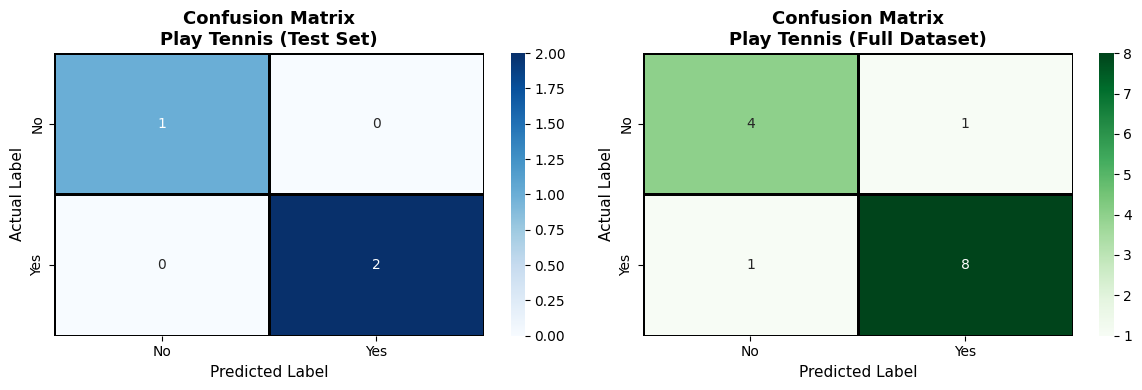

Plot saved: cm_play_tennis.png

   (b) MODEL EVALUATION - SOCIAL NETWORK ADS

Test Accuracy : 93.75%

Confusion Matrix:
[[50  2]
 [ 3 25]]

True  Negative  (TN) : 50
False Positive  (FP) : 2
False Negative  (FN) : 3
True  Positive  (TP) : 25

Precision : 0.9259
Recall    : 0.8929
F1 Score  : 0.9091

Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.94      0.96      0.95        52
    Purchased       0.93      0.89      0.91        28

     accuracy                           0.94        80
    macro avg       0.93      0.93      0.93        80
 weighted avg       0.94      0.94      0.94        80



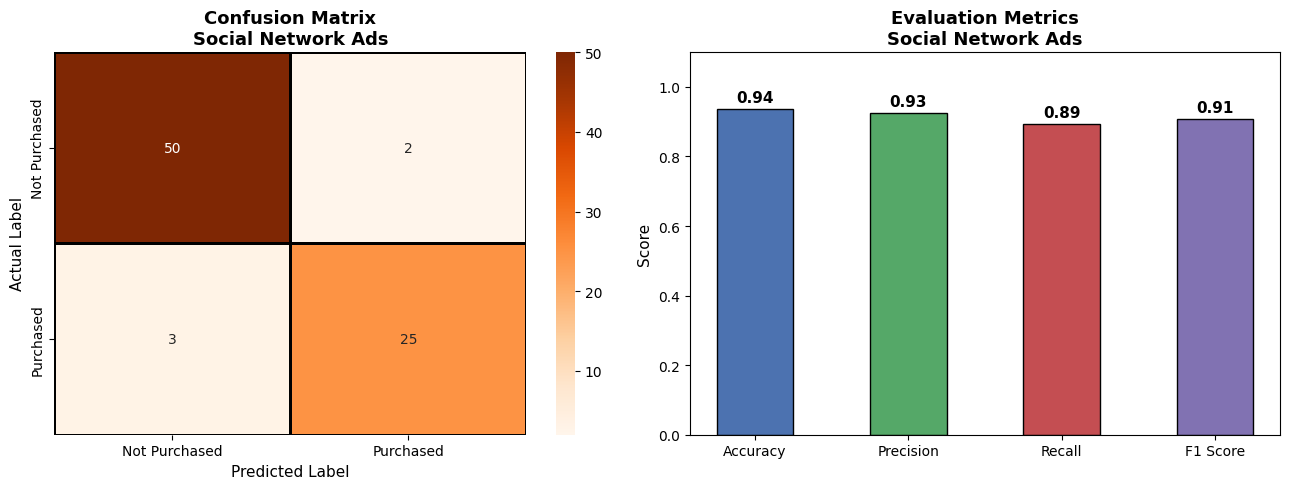

Plot saved: cm_social_network.png

Evaluation Complete!


In [4]:
# Block 4(b): Model Evaluation - Accuracy & Confusion Matrix

# ══════════════════════════════════════════════
# DATASET 1: PLAY TENNIS
# ══════════════════════════════════════════════

print("=" * 55)
print("   (b) MODEL EVALUATION - PLAY TENNIS")
print("=" * 55)

# Accuracy
pt_acc_test = accuracy_score(y_pt_test, y_pt_pred)
pt_acc_full = accuracy_score(y_pt, y_pt_pred_full)
print(f"\nTest  Accuracy : {pt_acc_test * 100:.2f}%")
print(f"Full  Accuracy : {pt_acc_full * 100:.2f}%")

# Confusion Matrix
cm_pt = confusion_matrix(y_pt_test, y_pt_pred)
print(f"\nConfusion Matrix (Test Set):\n{cm_pt}")

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_pt_test, y_pt_pred,
                            target_names=['No', 'Yes'],
                            zero_division=0))

# Full dataset confusion matrix
cm_pt_full = confusion_matrix(y_pt, y_pt_pred_full)
print(f"Confusion Matrix (Full Dataset):\n{cm_pt_full}")
print("\nClassification Report (Full Dataset):")
print(classification_report(y_pt, y_pt_pred_full,
                            target_names=['No', 'Yes'],
                            zero_division=0))

# Plot Confusion Matrix - Play Tennis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_title('Confusion Matrix\nPlay Tennis (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label', fontsize=11)

sns.heatmap(cm_pt_full, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            ax=axes[1], linewidths=1, linecolor='black')
axes[1].set_title('Confusion Matrix\nPlay Tennis (Full Dataset)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('Actual Label', fontsize=11)

plt.tight_layout()
plt.savefig('cm_play_tennis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: cm_play_tennis.png")

# ══════════════════════════════════════════════
# DATASET 2: SOCIAL NETWORK ADS
# ══════════════════════════════════════════════

print("\n" + "=" * 55)
print("   (b) MODEL EVALUATION - SOCIAL NETWORK ADS")
print("=" * 55)

# Accuracy
sn_acc = accuracy_score(y_sn_test, y_sn_pred)
print(f"\nTest Accuracy : {sn_acc * 100:.2f}%")

# Confusion Matrix
cm_sn = confusion_matrix(y_sn_test, y_sn_pred)
print(f"\nConfusion Matrix:\n{cm_sn}")

# Breakdown
tn, fp, fn, tp = cm_sn.ravel()
print(f"\nTrue  Negative  (TN) : {tn}")
print(f"False Positive  (FP) : {fp}")
print(f"False Negative  (FN) : {fn}")
print(f"True  Positive  (TP) : {tp}")
print(f"\nPrecision : {tp/(tp+fp):.4f}")
print(f"Recall    : {tp/(tp+fn):.4f}")
print(f"F1 Score  : {2*tp/(2*tp+fp+fn):.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_sn_test, y_sn_pred,
                            target_names=['Not Purchased', 'Purchased']))

# Plot Confusion Matrix - Social Network Ads
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_sn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Purchased','Purchased'],
            yticklabels=['Not Purchased','Purchased'],
            ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_title('Confusion Matrix\nSocial Network Ads', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label', fontsize=11)

# Bar chart of metrics
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_vals  = [sn_acc,
                tp/(tp+fp),
                tp/(tp+fn),
                2*tp/(2*tp+fp+fn)]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
bars = axes[1].bar(metrics, metric_vals, color=colors, edgecolor='black', width=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Evaluation Metrics\nSocial Network Ads', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=11)
for bar, val in zip(bars, metric_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('cm_social_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: cm_social_network.png")

print("\nEvaluation Complete!")

   (c) SCALER COMPARISON - SOCIAL NETWORK ADS

📊 StandardScaler Results:
   Accuracy  : 93.75%
   Precision : 0.9259
   Recall    : 0.8929
   F1 Score  : 0.9091
   Confusion Matrix:
[[50  2]
 [ 3 25]]

📊 MinMaxScaler Results:
   Accuracy  : 93.75%
   Precision : 0.9259
   Recall    : 0.8929
   F1 Score  : 0.9091
   Confusion Matrix:
[[50  2]
 [ 3 25]]

📋 Comparison Table:
        Scaler  Accuracy  Precision  Recall  F1 Score
StandardScaler     93.75     0.9259  0.8929    0.9091
  MinMaxScaler     93.75     0.9259  0.8929    0.9091

Classification Report - StandardScaler:
               precision    recall  f1-score   support

Not Purchased       0.94      0.96      0.95        52
    Purchased       0.93      0.89      0.91        28

     accuracy                           0.94        80
    macro avg       0.93      0.93      0.93        80
 weighted avg       0.94      0.94      0.94        80

Classification Report - MinMaxScaler:
               precision    recall  f1-score   supp

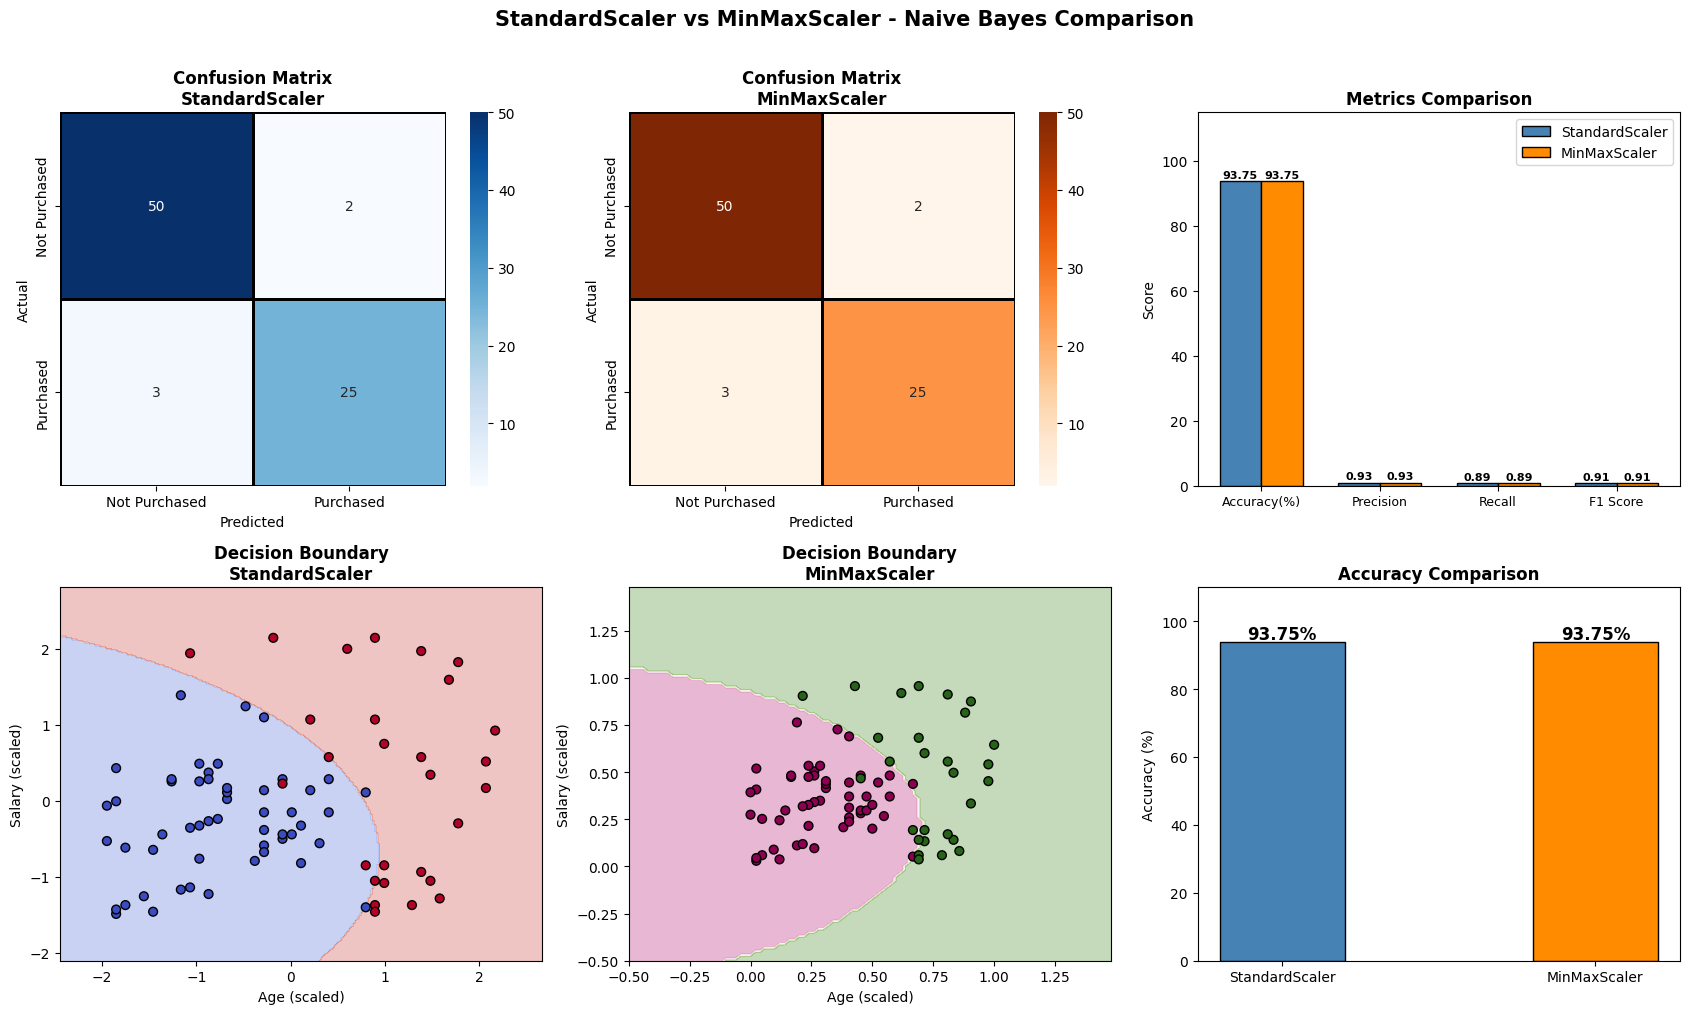


Plot saved: scaler_comparison.png

Scaler Comparison Complete!


In [5]:
# Block 5(c): Compare StandardScaler vs MinMaxScaler on Social Network Ads

print("=" * 60)
print("   (c) SCALER COMPARISON - SOCIAL NETWORK ADS")
print("=" * 60)

# ── Model with StandardScaler (already trained) ───────────────────
gnb_ss = GaussianNB()
gnb_ss.fit(X_sn_train_ss, y_sn_train)
y_pred_ss = gnb_ss.predict(X_sn_test_ss)

acc_ss  = accuracy_score(y_sn_test, y_pred_ss)
cm_ss   = confusion_matrix(y_sn_test, y_pred_ss)
tn,fp,fn,tp = cm_ss.ravel()
prec_ss = tp/(tp+fp)
rec_ss  = tp/(tp+fn)
f1_ss   = 2*tp/(2*tp+fp+fn)

# ── Model with MinMaxScaler ────────────────────────────────────────
gnb_mm = GaussianNB()
gnb_mm.fit(X_sn_train_mm, y_sn_train)
y_pred_mm = gnb_mm.predict(X_sn_test_mm)

acc_mm  = accuracy_score(y_sn_test, y_pred_mm)
cm_mm   = confusion_matrix(y_sn_test, y_pred_mm)
tn2,fp2,fn2,tp2 = cm_mm.ravel()
prec_mm = tp2/(tp2+fp2)
rec_mm  = tp2/(tp2+fn2)
f1_mm   = 2*tp2/(2*tp2+fp2+fn2)

# ── Print Comparison Table ─────────────────────────────────────────
print("\n📊 StandardScaler Results:")
print(f"   Accuracy  : {acc_ss*100:.2f}%")
print(f"   Precision : {prec_ss:.4f}")
print(f"   Recall    : {rec_ss:.4f}")
print(f"   F1 Score  : {f1_ss:.4f}")
print(f"   Confusion Matrix:\n{cm_ss}")

print(f"\n📊 MinMaxScaler Results:")
print(f"   Accuracy  : {acc_mm*100:.2f}%")
print(f"   Precision : {prec_mm:.4f}")
print(f"   Recall    : {rec_mm:.4f}")
print(f"   F1 Score  : {f1_mm:.4f}")
print(f"   Confusion Matrix:\n{cm_mm}")

# ── Summary DataFrame ──────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Scaler'    : ['StandardScaler', 'MinMaxScaler'],
    'Accuracy'  : [round(acc_ss*100,2), round(acc_mm*100,2)],
    'Precision' : [round(prec_ss,4),    round(prec_mm,4)],
    'Recall'    : [round(rec_ss,4),     round(rec_mm,4)],
    'F1 Score'  : [round(f1_ss,4),      round(f1_mm,4)]
})
print("\n📋 Comparison Table:")
print(comparison_df.to_string(index=False))

# ── Classification Reports ─────────────────────────────────────────
print("\nClassification Report - StandardScaler:")
print(classification_report(y_sn_test, y_pred_ss,
                            target_names=['Not Purchased','Purchased']))

print("Classification Report - MinMaxScaler:")
print(classification_report(y_sn_test, y_pred_mm,
                            target_names=['Not Purchased','Purchased']))

# ══════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('StandardScaler vs MinMaxScaler - Naive Bayes Comparison',
             fontsize=15, fontweight='bold', y=1.01)

# ── Row 1: Confusion Matrices ──────────────────────────────────────
sns.heatmap(cm_ss, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased','Purchased'],
            yticklabels=['Not Purchased','Purchased'],
            ax=axes[0,0], linewidths=1, linecolor='black')
axes[0,0].set_title('Confusion Matrix\nStandardScaler', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('Actual')

sns.heatmap(cm_mm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Purchased','Purchased'],
            yticklabels=['Not Purchased','Purchased'],
            ax=axes[0,1], linewidths=1, linecolor='black')
axes[0,1].set_title('Confusion Matrix\nMinMaxScaler', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('Actual')

# ── Grouped Bar - All Metrics ──────────────────────────────────────
metrics     = ['Accuracy(%)', 'Precision', 'Recall', 'F1 Score']
ss_vals     = [acc_ss*100, prec_ss, rec_ss, f1_ss]
mm_vals     = [acc_mm*100, prec_mm, rec_mm, f1_mm]

x = np.arange(len(metrics))
w = 0.35
bars1 = axes[0,2].bar(x - w/2, ss_vals, w, label='StandardScaler',
                       color='steelblue', edgecolor='black')
bars2 = axes[0,2].bar(x + w/2, mm_vals, w, label='MinMaxScaler',
                       color='darkorange', edgecolor='black')
axes[0,2].set_title('Metrics Comparison', fontsize=12, fontweight='bold')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(metrics, fontsize=9)
axes[0,2].set_ylim(0, 115)
axes[0,2].legend()
axes[0,2].set_ylabel('Score')
for bar in bars1:
    axes[0,2].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1, f'{bar.get_height():.2f}',
                   ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    axes[0,2].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1, f'{bar.get_height():.2f}',
                   ha='center', fontsize=8, fontweight='bold')

# ── Row 2: Decision Boundary Plots ────────────────────────────────
def plot_decision_boundary(ax, X_train, y_train, X_test, y_test,
                           model, title, cmap_bg='coolwarm'):
    h = 0.02
    x_min, x_max = X_train[:,0].min()-0.5, X_train[:,0].max()+0.5
    y_min, y_max = X_train[:,1].min()-0.5, X_train[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    scatter = ax.scatter(X_test[:,0], X_test[:,1], c=y_test,
                         cmap=cmap_bg, edgecolors='black', s=40)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age (scaled)'); ax.set_ylabel('Salary (scaled)')

plot_decision_boundary(axes[1,0],
                       X_sn_train_ss, y_sn_train,
                       X_sn_test_ss,  y_sn_test,
                       gnb_ss,
                       'Decision Boundary\nStandardScaler')

plot_decision_boundary(axes[1,1],
                       X_sn_train_mm, y_sn_train,
                       X_sn_test_mm,  y_sn_test,
                       gnb_mm,
                       'Decision Boundary\nMinMaxScaler',
                       cmap_bg='PiYG')

# ── Accuracy Bar ───────────────────────────────────────────────────
scalers  = ['StandardScaler', 'MinMaxScaler']
acc_vals = [acc_ss*100, acc_mm*100]
colors   = ['steelblue', 'darkorange']
bars = axes[1,2].bar(scalers, acc_vals, color=colors,
                      edgecolor='black', width=0.4)
axes[1,2].set_ylim(0, 110)
axes[1,2].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, acc_vals):
    axes[1,2].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1,
                   f'{val:.2f}%', ha='center',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('scaler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: scaler_comparison.png")
print("\nScaler Comparison Complete!")

In [6]:
# Block 6(d): Save trained models and scalers for deployment
import pickle, os

os.makedirs('naive_bayes_app', exist_ok=True)

# Save models and scalers
pickle.dump(gnb_ss, open('naive_bayes_app/model_social.pkl', 'wb'))
pickle.dump(ss,     open('naive_bayes_app/scaler_ss.pkl', 'wb'))
pickle.dump(mm,     open('naive_bayes_app/scaler_mm.pkl', 'wb'))
pickle.dump(gnb_pt, open('naive_bayes_app/model_tennis.pkl', 'wb'))

print("✅ Models saved:")
print("   naive_bayes_app/model_social.pkl")
print("   naive_bayes_app/scaler_ss.pkl")
print("   naive_bayes_app/scaler_mm.pkl")
print("   naive_bayes_app/model_tennis.pkl")

✅ Models saved:
   naive_bayes_app/model_social.pkl
   naive_bayes_app/scaler_ss.pkl
   naive_bayes_app/scaler_mm.pkl
   naive_bayes_app/model_tennis.pkl
